In [1]:
import zipfile
import os
from google.colab import files

# Upload ZIP file
uploaded = files.upload()

# Get ZIP filename
zip_file = list(uploaded.keys())[0]

# Extract ZIP
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully")

Saving part_2_cnn_computer_vision-20260511T170122Z-3-001.zip to part_2_cnn_computer_vision-20260511T170122Z-3-001.zip
Dataset Extracted Successfully


In [2]:
import os

print(os.listdir("dataset"))

['part_2_cnn_computer_vision']


In [3]:
dataset_path = "dataset"

print(os.listdir(dataset_path))

['part_2_cnn_computer_vision']


In [4]:
dataset_path = "dataset/part_2_cnn_computer_vision"

print(os.listdir(dataset_path))

['.DS_Store', 'images', 'labels.csv', 'data_dictionary.md']


In [6]:
!pip install tensorflow pandas matplotlib seaborn scikit-learn pillow

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [8]:
labels_df = pd.read_csv("dataset/part_2_cnn_computer_vision/labels.csv")

labels_df.head()

,filename,class
0,images/normal/normal_001.png,normal
1,images/normal/normal_002.png,normal
2,images/normal/normal_003.png,normal
3,images/normal/normal_004.png,normal
4,images/normal/normal_005.png,normal


In [11]:
print(labels_df['class'].value_counts())

class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


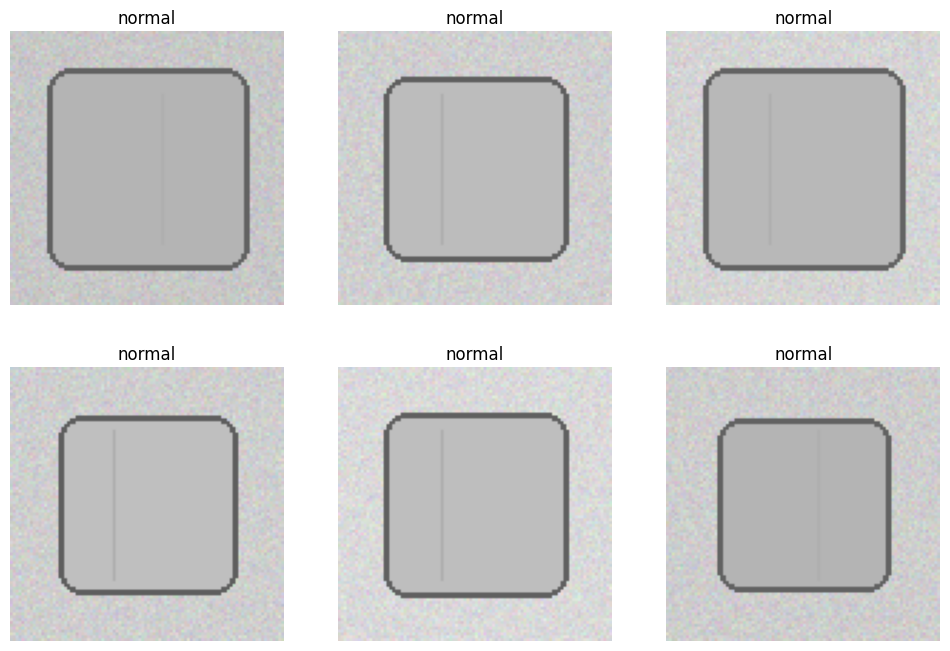

In [13]:
image_folder = "dataset/part_2_cnn_computer_vision"

plt.figure(figsize=(12,8))

for i in range(6):

    image_name = labels_df.iloc[i]['filename']

    img_path = os.path.join(image_folder, image_name)

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.title(labels_df.iloc[i]['class'])

    plt.axis('off')

plt.show()

In [14]:
IMG_SIZE = 128

images = []
labels = []

for index, row in labels_df.iterrows():

    img_path = os.path.join(
        "dataset/part_2_cnn_computer_vision",
        row['filename']
    )

    img = Image.open(img_path).convert('RGB')

    img = img.resize((IMG_SIZE, IMG_SIZE))

    img = np.array(img) / 255.0

    images.append(img)

    labels.append(row['class'])

X = np.array(images)

y = np.array(labels)

print(X.shape)
print(y.shape)

(480, 128, 128, 3)
(480,)


In [15]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()

y_encoded = le.fit_transform(y)

y_categorical = to_categorical(y_encoded)

print(y_categorical.shape)

(480, 4)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(384, 128, 128, 3)
(96, 128, 128, 3)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3)
))

# Pooling Layer
model.add(MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

# Second Pooling Layer
model.add(MaxPooling2D((2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(y_categorical.shape[1], activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 854ms/step - accuracy: 0.2541 - loss: 2.3940 - val_accuracy: 0.2338 - val_loss: 1.4000
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.2443 - loss: 1.4092 - val_accuracy: 0.2338 - val_loss: 1.3806
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 990ms/step - accuracy: 0.3094 - loss: 1.3824 - val_accuracy: 0.4156 - val_loss: 1.3795
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 721ms/step - accuracy: 0.3811 - loss: 1.3603 - val_accuracy: 0.2078 - val_loss: 1.4009
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 851ms/step - accuracy: 0.4560 - loss: 1.2927 - val_accuracy: 0.5325 - val_loss: 1.2393
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 796ms/step - accuracy: 0.5733 - loss: 1.1037 - val_accuracy: 0.4935 - val_loss: 1.0508
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 705ms/step - accuracy: 0.6840 - loss: 0.9079 - val_accuracy: 0.7013 - val_loss: 0.8134
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 835ms/step - accuracy: 0.7655 - loss: 0.6905 - val_accuracy: 0

In [21]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)

print("Test Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 338ms/step - accuracy: 0.8333 - loss: 0.5135
Test Loss: 0.5134506821632385
Test Accuracy: 0.8333333134651184


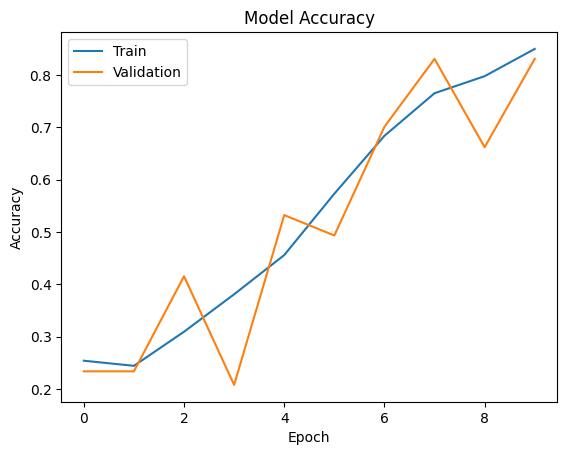

In [22]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 402ms/step


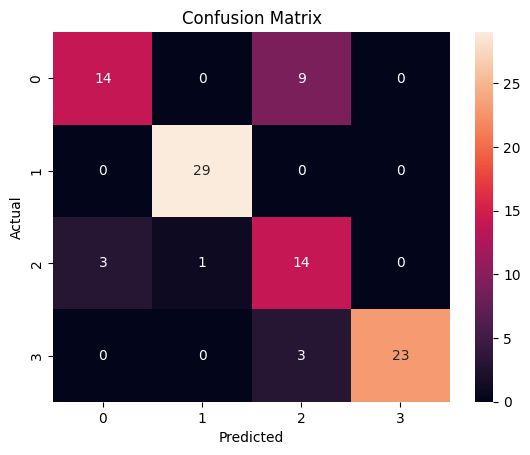

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.82      0.61      0.70        23
           1       0.97      1.00      0.98        29
           2       0.54      0.78      0.64        18
           3       1.00      0.88      0.94        26

    accuracy                           0.83        96
   macro avg       0.83      0.82      0.81        96
weighted avg       0.86      0.83      0.84        96



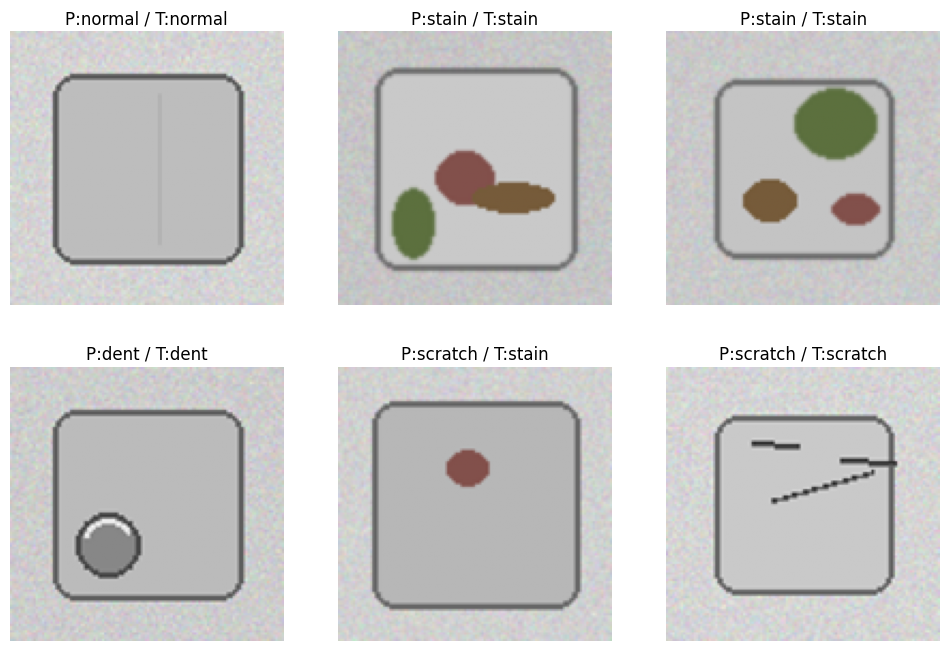

In [25]:
plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(X_test[i])

    pred_label = le.inverse_transform([y_pred_classes[i]])[0]

    true_label = le.inverse_transform([y_true[i]])[0]

    plt.title(f"P:{pred_label} / T:{true_label}")

    plt.axis('off')

plt.show()

Task 1: Problem Identification

The dataset represents an Image Classification problem because each image belongs to a predefined class category. The CNN model classifies images into their respective classes based on visual patterns.

Task 2: Dataset Exploration

- The dataset contains labeled images.
- Labels are stored in labels.csv.
- Class distribution was analyzed using value_counts().
- Sample images were visualized.
- Images were resized for CNN processing.

Task 3: Image Preprocessing

Image preprocessing included:
- Resizing images to 128x128
- Normalizing pixel values
- Label encoding
- Splitting into training and testing sets

Task 4: CNN Model Creation

The CNN model includes:
- Convolution layers
- ReLU activation
- MaxPooling layers
- Flatten layer
- Dense layer
- Softmax output layer

Task 5: Model Training and Evaluation

The CNN model was trained and evaluated using:
- Training accuracy
- Validation accuracy
- Confusion matrix
- Classification report
- Sample predictions

Task 6: CNN Concept Explanation

1. What is convolution?

Convolution extracts important visual features such as edges and textures from images.

2. Why is pooling used?

Pooling reduces image dimensions and computational complexity while preserving key features.

3. Why is ReLU commonly used in CNNs?

ReLU introduces non-linearity and improves learning efficiency.

4. Why are CNNs better than regular feed-forward networks for image data?

CNNs automatically learn spatial features from images and use fewer parameters compared to fully connected networks.

Task 7: Business Use Case Mapping

CNN-based image classification systems are widely used in healthcare for medical image analysis such as disease detection from X-rays and MRI scans.